In [1]:
import torch
from torchvision import transforms
import configparser
from PIL import Image
from pathlib import Path
import os
from tqdm import tqdm


In [2]:
data_path = Path(os.getcwd()).parent

In [3]:
# listado de imagenes para cada dataset
data_config = configparser.ConfigParser()
data_config.read(data_path/'data/splits/global_binaria.ini')

['c:\\Users\\gabim\\MiM\\data\\splits\\global_binaria.ini']

In [4]:
to_tensor = transforms.ToTensor()

images_path = data_config['split'].get('training').split(sep=',')
count = len(images_path)*512*512

In [5]:
sum_by_channel = torch.zeros(3)
for image in tqdm(images_path):
    img = Image.open(data_path/'data/images'/(image+'.png'))
    img = to_tensor(img)
    img = img.view(3,-1).sum(dim=1)
    sum_by_channel += img


img_mean = sum_by_channel/count
img_mean

100%|██████████| 41979/41979 [04:22<00:00, 159.77it/s]


tensor([0.4259, 0.2908, 0.1977])

In [6]:
sum_desv_by_channel = torch.zeros(3)
for image in tqdm(images_path):
    img = Image.open(data_path/'data/images'/(image+'.png'))
    img = to_tensor(img)
    img = img.view(3,-1)
    img = (img - img_mean.view(3,1))**2
    img = img.sum(dim=1)
    sum_desv_by_channel += img

img_std = (sum_desv_by_channel/count)**0.5
img_std

100%|██████████| 41979/41979 [04:30<00:00, 155.42it/s]


tensor([0.2751, 0.2001, 0.1651])

In [27]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
import configparser
from PIL import Image
from pathlib import Path
import os

class EyeDataset(torch.utils.data.dataset.Dataset):
  
  def __init__(self, partition, mean, std):
    '''
    - partition: 'training', 'validation' o 'test'
    - mean: media para normalizar los datos
    - std: desvío estándar
    '''
    super(EyeDataset, self).__init__()

    # chequeo de que no entre cualquier cosa en vez de partition
    assert partition in ['training', 'validation', 'test'], 'partition has to be training, validation or test, not {}'.format(partition)

    # transformaciones
    self.data_transforms = transforms.Compose([
      transforms.ToTensor(),
      transforms.Normalize(mean=mean, std=std)])
    
    self.data_path = Path(os.getcwd()).parent

    # listado de imagenes para cada dataset
    data_config = configparser.ConfigParser()
    data_config.read(self.data_path/'data/splits/global_binaria.ini')

    # listado de labels para cada imagen
    labels_config = configparser.ConfigParser()
    labels_config.read(self.data_path/'data/labels/global_labels.ini')

    self.data = [(image,
                  int(labels_config['label'].get(image)))
                  for image in data_config['split'].get(partition).split(sep=',')
                  ]
    
    # hacemos una lista de nombres para las clases
    self.class_names = ['buena', 'mala']


  def __len__(self):
    '''
    Método que devuelve la cantidad de elementos del dataset
    '''
    return len(self.data)
  
  def __getitem__(self, index):
    '''
    Método que devuelve el elemento index del dataset
    '''
    # obtengo la ruta de la imagen y su etiqueta asociada
    img_path, label = self.data[index]

    # cargo la imagen
    img = Image.open(self.data_path/'data/images'/(img_path+'.png'))
    # transformaciones
    img = self.data_transforms(img)

    # convierto la etiqueta en un tensor de tipo long
    label = torch.tensor(label)
    label = label.long()

    # retornamos el par
    return (img, label)

In [28]:
train = EyeDataset(partition='training',mean=img_mean,std=img_std)

In [31]:
torch.min(train[0][0]), torch.max(train[0][0])

(tensor(-1.5485), tensor(1.3314))

In [32]:
train[0][0].shape

torch.Size([3, 512, 512])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5484742..1.3313893].


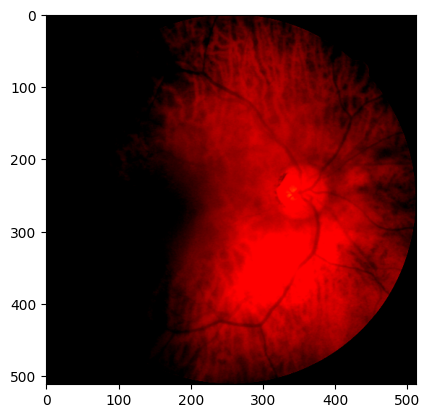

In [33]:
import matplotlib.pyplot as plt

plt.imshow(train[0][0].permute(1, 2, 0))